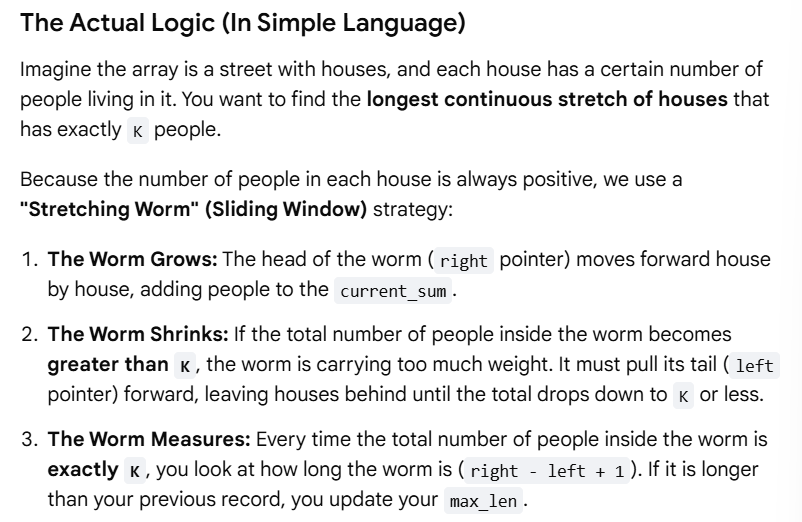

In [ ]:
#Longest subarray with sum k (positives) O(n)
#contigous part of array

def get_longest_subarray(arr: list[int], k: int) -> int:
    """Finds the length of the longest contiguous subarray with a sum equal to k.

    Works for arrays with positive integers.
    """
    left = 0
    current_sum = 0
    max_len = 0

    for right in range(len(arr)):
        # Early exit optimization: If the current element is larger than k
        # and the window is empty, no valid subarray can start here or later
        # (if sorted).
        if arr[right] > k and current_sum == 0:
            break #if my  first element greater no possibility to genrate
            #This KILLS the loop entirely!

        # Expand the window by adding the current element
        current_sum += arr[right]

        # Shrink the window from the left if the sum exceeds k
        while current_sum > k and left <= right:
            current_sum -= arr[left]
            left += 1

        # Record the length if the exact sum is found
        if current_sum == k:
            max_len = max(max_len, right - left + 1)

    return max_len


# ==========================================
# Test Cases
# ==========================================

# Test 1: Unsorted Array
nums_unsorted = [2, 3, 5, 1, 9]
target1 = 6
print(
    f"Unsorted Array Max Length: {get_longest_subarray(nums_unsorted, target1)}"
)
# Output: 2 (Subarray is [5, 1])

# Test 2: Sorted Array
nums_sorted = [1, 2, 3, 5, 9]
target2 = 6
print(f"Sorted Array Max Length: {get_longest_subarray(nums_sorted, target2)}")
# Output: 3 (Subarray is [1, 2, 3])




Unsorted Array Max Length: 2
Sorted Array Max Length: 3


In [ ]:
#If my  subarray is in descending order
def get_longest_subarray_universal(arr: list[int], k: int) -> int:
    left = 0
    current_sum = 0
    max_len = 0

    for right in range(len(arr)):
        # CHANGED TO CONTINUE: Safe for descending and unsorted arrays
        if arr[right] > k and current_sum == 0:
            left = right + 1  # Move the tail past this giant number
            continue  # Skip this element and move to the NEXT index

        current_sum += arr[right]

        while current_sum > k and left <= right:
            current_sum -= arr[left]
            left += 1

        if current_sum == k:
            max_len = max(max_len, right - left + 1)

    return max_len


# Example with Descending Array:
nums = [9, 5, 3, 2, 1]
print(get_longest_subarray_universal(nums, 6))  # Output: 3 (Subarray is [3, 2, 1])


3


Let's throw away the code and technical terms completely. Here is a real-world story to make this crystal clear.
## The Real-World Scenario: A Friend Borrowing Money
Imagine you have a friend who constantly borrows money from you and pays you back in random amounts over a week.

* Positive numbers (+) mean they borrowed money from you.
* Negative numbers (-) mean they paid you back.
* Zeros (0) mean nothing happened that day.

You want to find the longest streak of days where your friend net-borrowed exactly ₹6 from you.
Here is the log of what happened each day:

* Day 0: They borrow ₹1
* Day 1: They borrow ₹4
* Day 2: They pay you back ₹2 (-2)
* Day 3: They borrow ₹3
* Day 4: They borrow ₹1
* Day 5: They do nothing (0)
* Day 6: They pay you back ₹5 (-5)

------------------------------
## The Practical Tracking Trick
Instead of guessing, you just keep track of the Total Tab (the total amount they owe you since the very beginning) at the end of every day.
You write the total tab down in a notebook. Rule: If a specific total tab amount repeats, you never overwrite the older day. You want to keep the oldest day to make your streak as long as possible.
Before the week starts (Day -1), the tab is ₹0.

* Day 0: They take ₹1. Total Tab = ₹1.
* Day 1: They take ₹4. Total Tab = ₹5.
* Day 2: They give back ₹2. Total Tab = ₹3.
* Day 3: They take ₹3. Total Tab = ₹6.
* Wait! They owe you ₹6 right now. Since your starting tab was ₹0, the streak is from the start to Day 3. (Length = 4 days: Day 0, 1, 2, 3).
* Day 4: They take ₹1. Total Tab = ₹7.
* Ask yourself: To have a net change of ₹6, did the tab ever stand at ₹1 (7 - 6) in the past?
   * Look at your notebook: Yes! On Day 0, the tab was ₹1.
   * This means between Day 0 and Day 4, they net-borrowed exactly ₹6. (Length from Day 1 to Day 4 = 4 days).
* Day 5: They do nothing. Total Tab is still ₹7.
* Ask yourself: Did the tab ever stand at ₹1 (7 - 6) in the past?
   * Look at your notebook: Yes, the oldest time the tab was ₹1 was on Day 0.
   * This means between Day 0 and Day 5, they net-borrowed exactly ₹6. (Length from Day 1 to Day 5 = 5 days). 🏆 This is our new longest record!
* Day 6: They give back ₹5. Total Tab = ₹2.

------------------------------
## Why this works so easily
Look at that winning 5-day streak (Day 1 to Day 5). The daily actions were: [4, -2, 3, 1, 0].
If you add them up: $4 - 2 + 3 + 1 + 0 = 6$.
By simply looking at your total tab history, you found that exact group of days instantly without having to test every single combination.
Would you like to try tracking a different target amount using this same friend-and-tab notebook method to see how it feels?



In [ ]:
# Longest subarray with sum k (positives,negative,zero)  O(n)

def get_longest_borrowing_streak(days_log: list[int], target_amount: int) -> int:
    # This notebook keeps track of the Total Tab and the Day it first happened.
    # Format: {Total_Tab_Amount: Day_Number}
    # Before the week starts (Day -1), the friend owes you ₹0.
    notebook = {0: -1}

    current_total_tab = 0
    longest_streak = 0

    # Go through the transactions day by day
    for day in range(len(days_log)):
        # Update the total tab based on today's action (borrowing or paying back)
        current_total_tab += days_log[day]

        # We want to see if they net-borrowed exactly our target_amount (e.g., ₹6).
        # So we check if the tab was ever equal to (Current Tab - Target) in the past.
        past_tab_we_are_looking_for = current_total_tab - target_amount

        # Check your notebook to see if that past tab amount exists
        if past_tab_we_are_looking_for in notebook:
            # If it exists, calculate how many days have passed since that day
            start_day = notebook[past_tab_we_are_looking_for]
            current_streak_length = day - start_day

            # If this streak is longer than our previous record, update it!
            if current_streak_length > longest_streak:
                longest_streak = current_streak_length

        # CRITICAL RULE: Only write the current tab in the notebook if it's NEW.
        # If the tab amount already exists, do NOT overwrite it.
        # Keeping the oldest day makes sure our calculated streak stays as long as possible!
        if current_total_tab not in notebook:
            notebook[current_total_tab] = day

    # Return the longest record we found
    return longest_streak


# ========================================================
# Testing the code with our exact real-world scenario
# ========================================================

# Day 0: Borrow 1, Day 1: Borrow 4, Day 2: Pay back 2, Day 3: Borrow 3...
friend_transactions = [1, 4, -2, 3, 1, 0, -5]
target = 6

result = get_longest_borrowing_streak(friend_transactions, target)
print(f"The longest streak of days where they borrowed ₹6 is: {result} days")
# Output: The longest streak of days where they borrowed ₹6 is: 5 days
# (This represents the days: [4, -2, 3, 1, 0] which perfectly add up to 6)


The longest streak of days where they borrowed ₹6 is: 5 days


In [ ]:
#Two sum -> give me a+b = target


#Better approach -> Map data structure O(nlogn)
def two_sum_hashmap(arr: list[int], target: int) -> list[int]:
    # This notebook stores numbers we have already passed by.
    # Format: { Number_We_Saw : Its_Index_Position }
    notebook = {}

    for current_index in range(len(arr)):
        current_num = arr[current_index]

        # If my current number is 'A', I need to find 'B' such that A + B = Target.
        # This means B must equal (Target - A).
        needed_num = target - current_num

        # Check if the needed number 'B' is already written down in our notebook
        if needed_num in notebook:
            # Match found! Return the index of 'B' and the current index of 'A'
            return [notebook[needed_num], current_index]

        # If we haven't seen the needed number yet, write the current number
        # down in our notebook so future numbers can match with it.
        notebook[current_num] = current_index

    # Return empty list if no pair adds up to the target
    return []


# Example run:
nums = [2, 7, 11, 15]
target_val = 9
print(
    f"Hashmap Approach Indices: {two_sum_hashmap(nums, target_val)}"
)  # Output: [0, 1]



#Optimal approach -> Two pointer approach -> sort array first O(n)
def two_sum_twopointer(arr: list[int], target: int) -> bool:
    # STEP 1: Sort the array first.
    # This takes O(N log N) time, but it makes the array predictable.
    arr.sort()  # Array becomes ordered from smallest to largest

    # STEP 2: Set up two pointers (like two fingers tracing the list)
    left = 0  # Points to the smallest number at the start
    right = len(arr) - 1  # Points to the largest number at the end

    # Keep moving the pointers toward each other until they meet
    while left < right:
        current_sum = arr[left] + arr[right]

        # Case 1: Perfect Match!
        if current_sum == target:
            return True  # Found a pair that equals the target!

        # Case 2: The sum is too small.
        # Since the array is sorted, we can increase our sum by moving the
        # left pointer forward to point to a bigger number.
        elif current_sum < target:
            left += 1

        # Case 3: The sum is too big.
        # We can decrease our sum by moving the right pointer backward
        # to point to a smaller number.
        else:
            right -= 1

    return False  # Return False if the pointers meet and no pair was found


# Example run:
nums_list = [3, 2, 4]
target_val2 = 6
# The function will sort it to [2, 3, 4] and then find 2 + 4 = 6
print(
    f"Two-Pointer Pair Exists?: {two_sum_twopointer(nums_list, target_val2)}"
)  # Output: True



Hashmap Approach Indices: [0, 1]
Two-Pointer Pair Exists?: True


Here is the step-by-step dry run for the input array [2, 0, 2, 1, 1, 0].
## Initial Setup

* Pointers: low = 0, mid = 0, high = 5
* Array: [2, 0, 2, 1, 1, 0]

------------------------------
## Step-by-Step Execution## Iteration 1

* Pointers: low=0, mid=0, high=5
* Condition: mid <= high ($0 \le 5$) $\rightarrow$ True
* Action: arr[mid] is 2.
* Swap arr[mid] with arr[high].
   * Decrement high by 1.
* Array Change: [2, 0, 2, 1, 1, 0] $\rightarrow$ [0, 0, 2, 1, 1, 2]
* Next State: low=0, mid=0, high=4

## Iteration 2

* Pointers: low=0, mid=0, high=4
* Condition: mid <= high ($0 \le 4$) $\rightarrow$ True
* Action: arr[mid] is 0.
* Swap arr[mid] with arr[low] (swapping index 0 with itself).
   * Increment low and mid by 1.
* Array Change: No change [0, 0, 2, 1, 1, 2]
* Next State: low=1, mid=1, high=4

## Iteration 3

* Pointers: low=1, mid=1, high=4
* Condition: mid <= high ($1 \le 4$) $\rightarrow$ True
* Action: arr[mid] is 0.
* Swap arr[mid] with arr[low] (index 1 with index 1).
   * Increment low and mid by 1.
* Array Change: No change [0, 0, 2, 1, 1, 2]
* Next State: low=2, mid=2, high=4

## Iteration 4

* Pointers: low=2, mid=2, high=4
* Condition: mid <= high ($2 \le 4$) $\rightarrow$ True
* Action: arr[mid] is 2.
* Swap arr[mid] with arr[high] (index 2 with index 4).
   * Decrement high by 1.
* Array Change: [0, 0, 2, 1, 1, 2] $\rightarrow$ [0, 0, 1, 1, 2, 2]
* Next State: low=2, mid=2, high=3

## Iteration 5

* Pointers: low=2, mid=2, high=3
* Condition: mid <= high ($2 \le 3$) $\rightarrow$ True
* Action: arr[mid] is 1.
* Element is already in the middle zone.
   * Increment mid by 1.
* Array Change: No change [0, 0, 1, 1, 2, 2]
* Next State: low=2, mid=3, high=3

## Iteration 6

* Pointers: low=2, mid=3, high=3
* Condition: mid <= high ($3 \le 3$) $\rightarrow$ True
* Action: arr[mid] is 1.
* Element is already in the middle zone.
   * Increment mid by 1.
* Array Change: No change [0, 0, 1, 1, 2, 2]
* Next State: low=2, mid=4, high=3

------------------------------
## Termination

* Pointers: low=2, mid=4, high=3
* Condition: mid <= high ($4 \le 3$) $\rightarrow$ False
* Loop ends.

Final Sorted Array: [0, 0, 1, 1, 2, 2]
Would you like to analyze the time complexity of this trace or see how it handles edge cases like an array with only one number?



In [ ]:
#Sort 0's , 1's and 2's 
#Dutch National Flag algorithm (3 pointer) O(n)

def sort_012(arr):
    low = 0
    mid = 0
    high = len(arr) - 1

    while mid <= high:
        if arr[mid] == 0:
            # Swap current element with low and move both pointers
            arr[low], arr[mid] = arr[mid], arr[low]
            low += 1
            mid += 1
        elif arr[mid] == 1:
            # 1 is in the correct middle zone, just move mid
            mid += 1
        else:  # arr[mid] == 2
            # Swap current element with high and shrink high zone
            # Don't move mid yet; the new element at mid needs checking
            arr[high], arr[mid] = arr[mid], arr[high]
            high -= 1
    return arr

# Example usage
example = [2, 0, 2, 1, 1, 0]
print(f"Sorted: {sort_012(example)}") 
# Output: [0, 0, 1, 1, 2, 2]


Sorted: [0, 0, 1, 1, 2, 2]


In [ ]:
#Majority Elements (element appear more than > n/2 times)
#TC : O(N)   SC : O(N)

def find_majority_element(nums):
    # Dictionary to store frequencies
    counts = {}
    majority_threshold = len(nums) // 2
    
    # Count frequencies of each element
    for num in nums:
        counts[num] = counts.get(num, 0) + 1
        #if num not present default value is 0 otherwise add 1

        # Check immediately if current element crossed threshold
        if counts[num] > majority_threshold:
            return num
            
    return -1  # Return -1 if no majority element exists

# Example usage
example_array = [2, 2, 1, 1, 1, 2, 2]
result = find_majority_element(example_array)
print(f"The majority element is: {result}")
# Output: 2


The majority element is: 2


In [ ]:
#Moore Voting Algorithm TC : O(N)      SC : O(1)

def majority_element(v):
    # ==========================================
    # PHASE 1: Find a potential candidate (el)
    # ==========================================
    cnt = 0   # Keeps track of the "votes" or balance for our candidate
    el = None # Stores our current candidate element

    for i in range(len(v)):
        # If the count drops to 0, pick the current element as the new candidate
        if cnt == 0:
            cnt = 1
            el = v[i]
            
        # If the current element matches our candidate, increment the vote count
        elif v[i] == el:
            cnt += 1
            
        # If it's a different element, they cancel each other out (decrement count)
        else:
            cnt -= 1

    # ==========================================
    # PHASE 2: Verify the candidate
    # ==========================================
    # Phase 1 only guarantees a candidate, it doesn't guarantee a majority.
    # We must manually count how many times 'el' actually appears.
    cnt1 = 0
    for i in range(len(v)):
        if v[i] == el:
            cnt1 += 1

    # Check if the total occurrence is strictly greater than half the size
    if cnt1 > (len(v) // 2):
        return el  # Candidate verified!

    return -1  # Return -1 if no true majority element exists

# Size is 7. Majority threshold is 7 // 2 = 3.
# The number 2 appears 4 times, which is > 3.
input_array = [2, 2, 1, 1, 1, 2, 2]

# Run the function
result = majority_element(input_array)

# Display the output
print(f"Input Array: {input_array}")
print(f"The majority element is: {result}")


Input Array: [2, 2, 1, 1, 1, 2, 2]
The majority element is: 2


Here is the step-by-step dry run for the input array [-2, 1, -3, 4, -1, 2, 1, -5, 4].
Initially, max_sum = -inf, curr_sum = 0, start = 0, end = 0, and start_track = 0.
------------------------------
## Step-by-Step Execution## Index 0 (num = -2)

* curr_sum becomes: 0 + (-2) = -2
* Is -2 > -inf? Yes $\rightarrow$ max_sum = -2, start = 0, end = 0
* Is curr_sum < 0? Yes $\rightarrow$ curr_sum = 0, start_track = 1

## Index 1 (num = 1)

* curr_sum becomes: 0 + 1 = 1
* Is 1 > -2? Yes $\rightarrow$ max_sum = 1, start = 1, end = 1
* Is curr_sum < 0? No

## Index 2 (num = -3)

* curr_sum becomes: 1 + (-3) = -2
* Is -2 > 1? No
* Is curr_sum < 0? Yes $\rightarrow$ curr_sum = 0, start_track = 3

## Index 3 (num = 4)

* curr_sum becomes: 0 + 4 = 4
* Is 4 > 1? Yes $\rightarrow$ max_sum = 4, start = 3, end = 3
* Is curr_sum < 0? No

## Index 4 (num = -1)

* curr_sum becomes: 4 + (-1) = 3
* Is 3 > 4? No
* Is curr_sum < 0? No

## Index 5 (num = 2)

* curr_sum becomes: 3 + 2 = 5
* Is 5 > 4? Yes $\rightarrow$ max_sum = 5, start = 3, end = 5
* Is curr_sum < 0? No

## Index 6 (num = 1)

* curr_sum becomes: 5 + 1 = 6
* Is 6 > 5? Yes $\rightarrow$ max_sum = 6, start = 3, end = 6 (Max sum locked)
* Is curr_sum < 0? No

## Index 7 (num = -5)

* curr_sum becomes: 6 + (-5) = 1
* Is 1 > 6? No
* Is curr_sum < 0? No

## Index 8 (num = 4)

* curr_sum becomes: 1 + 4 = 5
* Is 5 > 6? No
* Is curr_sum < 0? No

------------------------------
## Final Extraction
At the end of the loop, the tracker variables hold:

* start = 3
* end = 6
* max_sum = 6

The code cuts the array from index 3 up to (and including) index 6: nums[3:7].
Final Result: [4, -1, 2, 1] with a sum of 6.



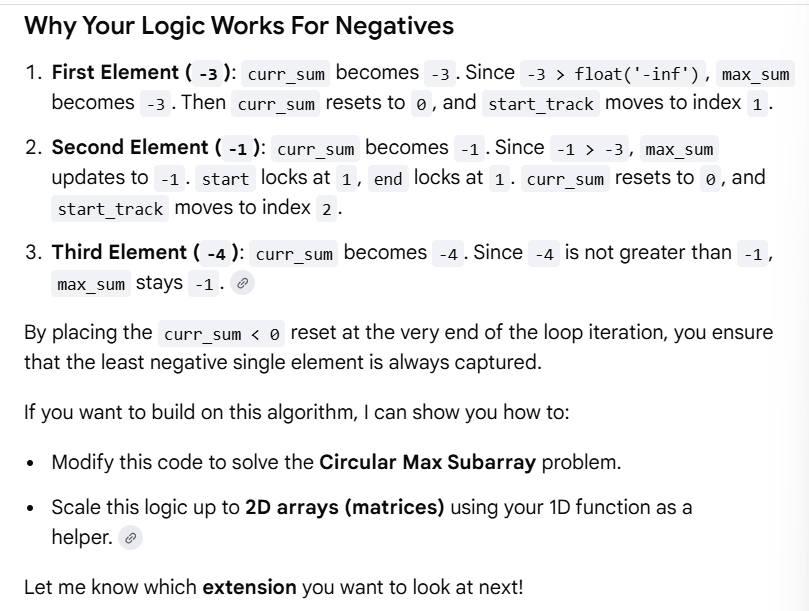


In [1]:
#Kadane's Algorithm

def max_subarray_with_printing(nums):
    max_sum = float('-inf')
    curr_sum = 0
    
    # Boundary tracking variables
    start = 0
    end = 0
    start_track = 0  # Tracks where the current subarray started
    
    for i in range(len(nums)):
        curr_sum += nums[i]
        
        # When a new maximum is found, lock in the indices
        if curr_sum > max_sum:
            max_sum = curr_sum
            start = start_track
            end = i
            
        # If current sum drops below zero, reset it and shift starting tracking point
        if curr_sum < 0:
            curr_sum = 0
            start_track = i + 1
            
    # Extract the actual subarray slice using the tracked indices
    result_subarray = nums[start:end + 1]
    return max_sum, result_subarray


# ==========================================
# TEST INPUT EXAMPLE
# ==========================================
input_array = [-2, 1, -3, 4, -1, 2, 1, -5, 4]

# Run the function
max_sum, subarray = max_subarray_with_printing(input_array)

# Display the output
print(f"Input Array: {input_array}")
print(f"Maximum Subarray Sum is: {max_sum}")
print(f"The Respective Subarray is: {subarray}")


# Test with all negative numbers
input_array = [-3, -1, -4, -2]

max_sum, subarray = max_subarray_with_printing(input_array)

print(f"Maximum Subarray Sum is: {max_sum}")
print(f"The Respective Subarray is: {subarray}")



Input Array: [-2, 1, -3, 4, -1, 2, 1, -5, 4]
Maximum Subarray Sum is: 6
The Respective Subarray is: [4, -1, 2, 1]
Maximum Subarray Sum is: -1
The Respective Subarray is: [-1]


In [ ]:
#Rearrange array elemnts by sign (i.e + - + - + .....) TC : O(n)  SC : O(n)

def rearrange_array_by_sign(nums):
    n = len(nums)
    # Create a result array of the same size
    result = [0] * n
    
    # Initialize pointers for even (positive) and odd (negative) indices
    pos_index = 0
    neg_index = 1
    
    # Iterate through the original array once
    for num in nums:
        if num > 0:
            # Place positive numbers at even positions (0, 2, 4...)
            result[pos_index] = num
            pos_index += 2
        else:
            # Place negative numbers at odd positions (1, 3, 5...)
            result[neg_index] = num
            neg_index += 2
            
    return result

# Example usage:
nums = [3, 1, -2, -5, 2, -4]
print(rearrange_array_by_sign(nums)) 
# Output: [3, -2, 1, -5, 2, -4]




[3, -2, 1, -5, 2, -4]


In [3]:
#Rearrange array elemnts by sign variety 2 unequal number

def rearrange_array_unequal(nums):
    # Step 1: Separate positives and negatives into two lists
    positives = []
    negatives = []
    
    for num in nums:
        if num >= 0:
            positives.append(num)
        else:
            negatives.append(num)
            
    result = []
    i, j = 0, 0
    
    # Step 2: Alternate elements as long as both lists have elements
    while i < len(positives) and j < len(negatives):
        result.append(positives[i])
        result.append(negatives[j])
        i += 1
        j += 1
        
    # Step 3: Append the remaining elements from the longer list
    if i < len(positives):
        result.extend(positives[i:])
    else:
        result.extend(negatives[j:])
        
    return result

# Example 1: More Positives
nums1 = [12, 11, -13, -5, 6, -7, 5, 2, 3]
print(rearrange_array_unequal(nums1))
# Output: [12, -13, 11, -5, 6, -7, 5, 2, 3]

# Example 2: More Negatives
nums2 = [-1, 3, -2, -5, -4]
print(rearrange_array_unequal(nums2))
# Output: [3, -1, -2, -5, -4]


[12, -13, 11, -5, 6, -7, 5, 2, 3]
[3, -1, -2, -5, -4]
